In [1]:
import nannyml
import pandas as pd
import os

d:\pypipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ref_df = pd.read_parquet(os.path.join("D:/pypipeline/data/processed/hourly/us_paro_hourly", "test_processed.parquet"))
ref_df = ref_df.reset_index()
ref_df["date"] = pd.to_datetime(ref_df["date"], utc=True, errors="coerce").dt.tz_convert("Asia/Kathmandu").dt.tz_localize(None)


In [3]:
cols = [
    c for c in ref_df.columns
    if c not in [
        "timestamp",
        "date",
        "pm25_target",
        "o3_target",
    ]
    + [f"pm25_plus_{h}h" for h in range(25)]
    + [f"o3_plus_{h}h" for h in range(25)]
]

In [4]:
ref_df

,date,pm25,o3,pm25_target,o3_target,hour,day_of_week,is_weekend,is_night,hour_sin,...,pm25_plus_20h,o3_plus_20h,pm25_plus_21h,o3_plus_21h,pm25_plus_22h,o3_plus_22h,pm25_plus_23h,o3_plus_23h,pm25_plus_24h,o3_plus_24h
0,2020-08-04 10:00:00,16.0,0.039,16.0,0.039,10,1,0,0,5.000000e-01,...,6.0,0.008,5.0,0.007,6.0,0.010,7.0,0.014,7.0,0.019
1,2020-08-04 11:00:00,16.0,0.039,16.0,0.039,11,1,0,0,2.588190e-01,...,5.0,0.007,6.0,0.010,7.0,0.014,7.0,0.019,8.0,0.034
2,2020-08-04 12:00:00,NaN,NaN,NaN,NaN,12,1,0,0,1.224647e-16,...,6.0,0.010,7.0,0.014,7.0,0.019,8.0,0.034,11.0,0.046
3,2020-08-04 13:00:00,NaN,NaN,NaN,NaN,13,1,0,0,-2.588190e-01,...,7.0,0.014,7.0,0.019,8.0,0.034,11.0,0.046,14.0,0.051
4,2020-08-04 14:00:00,NaN,NaN,NaN,NaN,14,1,0,0,-5.000000e-01,...,7.0,0.019,8.0,0.034,11.0,0.046,14.0,0.051,9.0,0.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5290,2021-03-12 20:00:00,58.0,0.039,58.0,0.039,20,4,0,0,-8.660254e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5291,2021-03-12 21:00:00,58.0,0.030,58.0,0.030,21,4,0,0,-7.071068e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5292,2021-03-12 22:00:00,60.0,0.030,60.0,0.030,22,4,0,0,-5.000000e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5293,2021-03-12 23:00:00,69.0,0.030,69.0,0.030,23,4,0,0,-2.588190e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Load predictions

In [5]:
preds = pd.read_csv(r"D:\pypipeline\data\predictions\hourly\us_paro_hourly\test\hourly_pm25_predictions.csv")
preds["date"] = pd.to_datetime(preds["date"], utc=True, errors="coerce").dt.tz_convert("Asia/Kathmandu").dt.tz_localize(None)


In [6]:
preds

,date,pm25_plus_1h_pred,pm25_plus_1h_true,pm25_plus_2h_pred,pm25_plus_2h_true,pm25_plus_3h_pred,pm25_plus_3h_true,pm25_plus_4h_pred,pm25_plus_4h_true,pm25_plus_5h_pred,...,pm25_plus_20h_pred,pm25_plus_20h_true,pm25_plus_21h_pred,pm25_plus_21h_true,pm25_plus_22h_pred,pm25_plus_22h_true,pm25_plus_23h_pred,pm25_plus_23h_true,pm25_plus_24h_pred,pm25_plus_24h_true
0,2020-08-04 10:00:00,15.230710,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,54.531612,6.0,46.345750,5.0,46.253605,6.0,41.358240,7.0,30.256626,7.0
1,2020-08-04 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,38.337414,5.0,33.031273,6.0,26.796686,7.0,21.132490,7.0,26.446306,8.0
2,2020-08-04 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.565560,6.0,29.279243,7.0,26.632483,7.0,28.411629,8.0,29.087063,11.0
3,2020-08-04 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,26.577879,7.0,23.293846,7.0,23.479021,8.0,32.683580,11.0,27.538948,14.0
4,2020-08-04 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.676025,7.0,22.130890,8.0,23.105795,11.0,31.115220,14.0,28.684300,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,2021-03-12 19:00:00,65.191414,58.0,74.929140,58.0,82.247440,60.0,91.502106,69.0,84.71132,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5106,2021-03-12 20:00:00,68.491460,58.0,86.550766,60.0,90.791900,69.0,80.991670,69.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5107,2021-03-12 21:00:00,69.769350,60.0,87.519710,69.0,78.934265,69.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5108,2021-03-12 22:00:00,70.645850,69.0,68.955520,69.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Join

In [7]:
merged_df = pd.merge(ref_df, preds, on="date", how="inner")

In [8]:
merged_df

,date,pm25,o3,pm25_target,o3_target,hour,day_of_week,is_weekend,is_night,hour_sin,...,pm25_plus_20h_pred,pm25_plus_20h_true,pm25_plus_21h_pred,pm25_plus_21h_true,pm25_plus_22h_pred,pm25_plus_22h_true,pm25_plus_23h_pred,pm25_plus_23h_true,pm25_plus_24h_pred,pm25_plus_24h_true
0,2020-08-04 10:00:00,16.0,0.039,16.0,0.039,10,1,0,0,5.000000e-01,...,54.531612,6.0,46.345750,5.0,46.253605,6.0,41.358240,7.0,30.256626,7.0
1,2020-08-04 11:00:00,16.0,0.039,16.0,0.039,11,1,0,0,2.588190e-01,...,38.337414,5.0,33.031273,6.0,26.796686,7.0,21.132490,7.0,26.446306,8.0
2,2020-08-04 12:00:00,NaN,NaN,NaN,NaN,12,1,0,0,1.224647e-16,...,30.565560,6.0,29.279243,7.0,26.632483,7.0,28.411629,8.0,29.087063,11.0
3,2020-08-04 13:00:00,NaN,NaN,NaN,NaN,13,1,0,0,-2.588190e-01,...,26.577879,7.0,23.293846,7.0,23.479021,8.0,32.683580,11.0,27.538948,14.0
4,2020-08-04 14:00:00,NaN,NaN,NaN,NaN,14,1,0,0,-5.000000e-01,...,18.676025,7.0,22.130890,8.0,23.105795,11.0,31.115220,14.0,28.684300,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,2021-03-12 19:00:00,55.0,0.044,55.0,0.044,19,4,0,0,-9.659258e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5106,2021-03-12 20:00:00,58.0,0.039,58.0,0.039,20,4,0,0,-8.660254e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5107,2021-03-12 21:00:00,58.0,0.030,58.0,0.030,21,4,0,0,-7.071068e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5108,2021-03-12 22:00:00,60.0,0.030,60.0,0.030,22,4,0,0,-5.000000e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## for t+1 as a test


In [9]:
h = 1

analysis = nannyml.DLE(y_true=f"pm25_plus_{h}h_true", 
                       y_pred=f"pm25_plus_{h}h_pred",
                       feature_column_names=cols, 
                       timestamp_column_name="date", 
                       chunk_period="2w",
                       metrics=["rmse","mae"])

In [10]:
# Fit the estimator
analysis.fit(merged_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11670
[LightGBM] [Info] Number of data points in the train set: 4982, number of used features: 76
[LightGBM] [Info] Start training from score 383.357349
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002805 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11670
[LightGBM] [Info] Number of data points in the train set: 4982, number of used features: 76
[LightGBM] [Info] Start training from score 9.492921


#### Use of refdf as a experiment on production using real data

In [ ]:
result = analysis.estimate(merged_df)
result.plot().show()

#### Residual Plot for 1h

<Axes: title={'center': 'PM2.5 t+1h: true vs predicted'}, xlabel='date'>

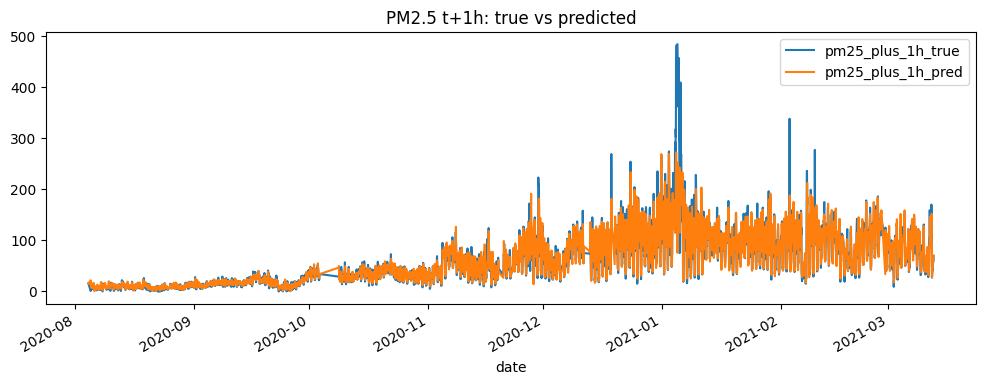

In [12]:
plot_df = merged_df[["date", f"pm25_plus_{h}h_true", f"pm25_plus_{h}h_pred"]].dropna().sort_values("date")
plot_df = plot_df.set_index("date")
plot_df.plot(figsize=(12, 4), title=f"PM2.5 t+{h}h: true vs predicted")